# SIH26168 Colab Training — AVNetLite on IO-VNBD
Target 95% accuracy (<5% drift). Run all cells in order. T4 GPU recommended.

In [1]:
!git clone https://github.com/Himanshu121865/sih26168.git
%cd sih26168
!pip install torch --index-url https://download.pytorch.org/whl/cu121 -q
!pip install pandas scipy onnx onnxruntime onnxscript loguru matplotlib scikit-learn -q
import torch; print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

Cloning into 'sih26168'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 28 (delta 1), reused 28 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 56.41 KiB | 18.80 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/sih26168
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 21.2 MB/s eta 0:00:00
True Tesla T4


In [2]:
!python python/download_iovnbd.py --subset Sync
!ls -lh data/iovnbd/*.zip
!python python/preprocess.py --subset 1h --window 200 --stride 10 --hz 100
!ls -lh data/processed/ && cat python/scaler.json | head -20

[dl] https://media.githubusercontent.com/media/onyekpeu/IO-VNBD/master/Synchronised%20V%20abd%20S%20datasets.zip -> data/iovnbd/Synchronised V abd S datasets.zip (203.6 MB)
  99.8%
[done] data/iovnbd/Synchronised V abd S datasets.zip 203606286 bytes
[unzip] data/iovnbd/Synchronised V abd S datasets.zip -> data/iovnbd/
[unzip] done [PosixPath('data/iovnbd/Synchronised V abd S datasets/Uncategorised IOVNB Dataset'), PosixPath('data/iovnbd/Synchronised V abd S datasets/Categorised IOVNB Dataset')]
[ok] download_iovnbd done
-rw-r--r-- 1 root root 195M Aug 29 19:47 'data/iovnbd/Synchronised V abd S datasets.zip'
[preprocess] 3 S files, window=200 stride=10 hz=100
[ok] M (Driver B)/S-M.csv: T=105974->617597 windows=61740
[ok] S1/S-S1.csv: T=51746->517450 windows=51726
[ok] S2/S-S2.csv: T=93876->920110 windows=91992
[concat] X (205458, 200, 6) v (205458,) X mean [-5.4421768e-02  1.8794918e-03  9.8548746e+00  1.1172646e-03
 -1.0447062e-02  2.2047269e-03] std [1.0462564  1.0249243  0.522433   0

In [3]:
!PYTHONPATH=. python python/train_avnet.py --epochs 50 --batch 128 --lr 1e-3 --device cuda
!ls -lh experiments/checkpoints/

[train] device cuda epochs 50 batch 128 lr 0.001
[dataset] npy mode data/processed/train_windows.npy
[dataset] npy mode data/processed/val_windows.npy
[data] train 164366 val 41092
[model] params 460,136
[epoch 1/50] train MSE 1.1366 val MSE 0.9573 lr 1.00e-03 15.1s
  [save] experiments/checkpoints/model_avnet_stage1.p best 0.9573
[epoch 2/50] train MSE 0.9062 val MSE 0.8239 lr 1.00e-03 10.4s
  [save] experiments/checkpoints/model_avnet_stage1.p best 0.8239
[epoch 3/50] train MSE 0.8046 val MSE 0.7602 lr 1.00e-03 10.7s
  [save] experiments/checkpoints/model_avnet_stage1.p best 0.7602
[epoch 4/50] train MSE 0.7284 val MSE 0.7427 lr 1.00e-03 10.3s
  [save] experiments/checkpoints/model_avnet_stage1.p best 0.7427
[epoch 5/50] train MSE 0.6722 val MSE 0.6861 lr 1.00e-03 9.7s
  [save] experiments/checkpoints/model_avnet_stage1.p best 0.6861
[epoch 6/50] train MSE 0.6263 val MSE 0.6114 lr 1.00e-03 10.5s
  [save] experiments/checkpoints/model_avnet_stage1.p best 0.6114
[epoch 7/50] train MSE 

[dataset] npy mode data/processed/val_windows.npy
[mse] val MSE 0.3361 RMSE 0.5798 m/s
/content/sih26168/python/eval_drift.py:82: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  xb = torch.from_numpy(X_seg[i:i+64])
[eval] segment 600 windows (60s) total_dist 138.4m
  naive final 16.4m drift 11.8%
  AI final 4.6m drift 3.3%
  AI+map final 2.8m drift 2.0%
[plot] saved reports/drift_plot.png


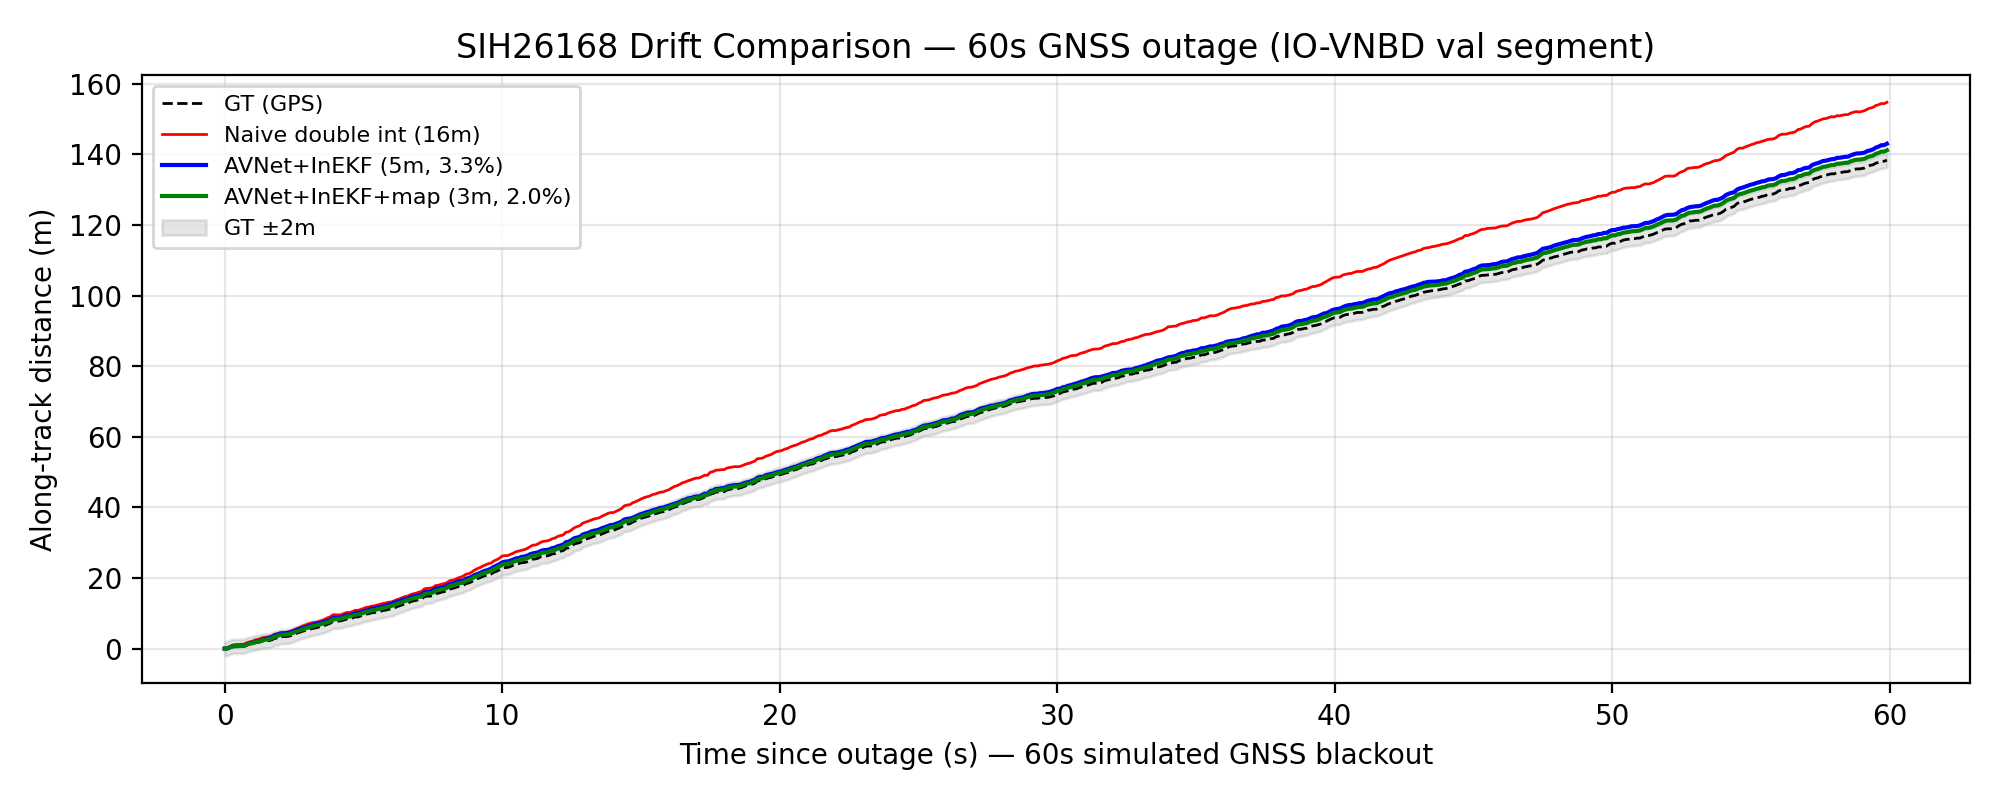

In [4]:
!PYTHONPATH=. python python/eval_drift.py --model experiments/checkpoints/model_avnet_stage1.p --plot reports/drift_plot.png
from IPython.display import Image; Image("reports/drift_plot.png")

In [5]:
!PYTHONPATH=. python python/export_tflite.py --model experiments/checkpoints/model_avnet_stage1.p --out model.tflite --onnx model.onnx
!ls -lh model.* scaler.json
!zip -r screening.zip model.tflite scaler.json reports/drift_plot.png python/scaler.json
!ls -lh screening.zip

[load] experiments/checkpoints/model_avnet_stage1.p
[model] 460,136 params, est FP32 1.84 MB FP16 0.92 MB
/content/sih26168/python/export_tflite.py:21: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0829 19:56:32.176000 6167 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
[torch.onnx] Obtain model graph for `AVNetLite([...]` with `torch.export.export(..., strict=False)`...
/usr/li